# 🦠 **Compartmental Epidemic Models: SIR and SEIR**

## **1. Introduction to Compartmental Epidemic Models**

Epidemic modeling is a core component of public health analytics.

Among mechanistic epidemic models, compartmental models are the most widely used because they explicitly describe how individuals transition between disease states.

**The main idea is simple:**

- Divide the population into compartments based on disease status and model how individuals move between them over time.

**These models help us:**

- understand disease transmission mechanisms,

- identify key epidemiological parameters,

- evaluate intervention strategies such as vaccination or isolation.

## **2. The SIR Model (Kermack - McKendrick, 1927)**

**Population Structure**

The population is divided into three compartments:

**S(t)**: Susceptible individuals

**I(t)**: Infectious individuals

**R(t)**: Recovered (removed) individuals

The total population size is assumed to be fixed:



> N=S(t)+I(t)+R(t)



## **3. Conceptual Flow of the SIR Model**

Susceptible (S) → Infectious (I) → Recovered (R)

- Susceptible individuals become infected through contact with infectious individuals

- Infected individuals eventually recover

- Recovered individuals acquire permanent immunity

## **4. SIR Model Differential Equations**

The dynamics of the SIR model are described by the following system of ordinary differential equations:


> dS/dt = - β [S(t)I(t)]/N

> dI/dt = β [S(t)I(t)]/N -γI(t)

> dR/dt = γI(t)



## **5. Interpretation of Parameters**
- β (beta): Effective contact rate

          β combines:

            probability of infection per contact

            average number of contacts per unit time

- γ (gamma): Recovery rate


         γ^(-1) = average infectious period

## **6. Normalized (Proportion-Based) SIR Model**


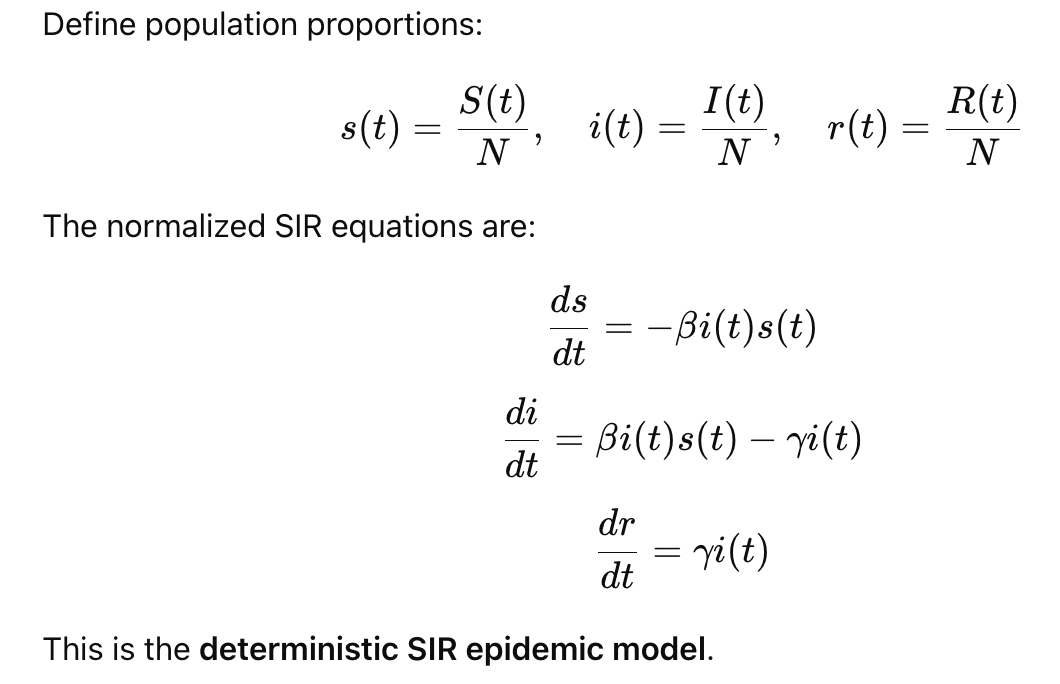




## **7. Assumptions of the Basic SIR Model**

The SIR model assumes:

- Closed population (no births or deaths)

- Constant transmission and recovery rates

- No demographic (natural death and birth) structure

- Homogeneous mixing (everyone contacts everyone equally)

- Permanent immunity after recovery

## **8. Simulating the SIR Model in Python**
Import Required Libraries

In [ ]:
# numpy lib, integrate is a sub-package (or module) within the SciPy library, odeint is a function
import numpy as np
from scipy.integrate import odeint
import matplotlib.pyplot as plt


Define the SIR Model

In [ ]:
def sir_model(y, t, beta, gamma):
    S, I, R = y
    dSdt = -beta * S * I
    dIdt = beta * S * I - gamma * I
    dRdt = gamma * I
    return [dSdt, dIdt, dRdt]


Initial Conditions and Parameters

In [ ]:
S0 = 0.999
I0 = 0.001
R0 = 0.0

beta = 0.3
gamma = 0.1

t = np.linspace(0, 300, 301)


Solve the ODE System

In [ ]:
solution = odeint(sir_model, [S0, I0, R0], t, args=(beta, gamma))
S, I, R = solution.T
'''
solution.T rearranges the ODE output so that each compartment (S, I, R)
becomes a separate time series, making it easy to analyze, print, and plot.
'''
print(solution.shape)
print(S.shape, I.shape, R.shape)
print("S:", S[:10])
print("I:", I[:10])
print("R:", R[:10])


(301, 3)
(301,) (301,) (301,)
S: [0.999      0.99866833 0.99826354 0.99776961 0.99716707 0.99643224
 0.99553642 0.99444483 0.99311543 0.99149746]
I: [0.001      0.00122099 0.00149064 0.0018196  0.00222078 0.00270988
 0.00330589 0.00403179 0.00491528 0.00598974]
R: [0.         0.00011069 0.00024582 0.0004108  0.00061215 0.00085788
 0.00115769 0.00152339 0.00196929 0.0025128 ]


In [ ]:
import pandas as pd

df = pd.DataFrame({
    "time": t,
    "Susceptible": S,
    "Infected": I,
    "Recovered": R
})
df.head()
(df["Susceptible"] + df["Infected"] + df["Recovered"]).head()

,0
0,1.0
1,1.0
2,1.0
3,1.0
4,1.0


Plot the SIR Dynamics

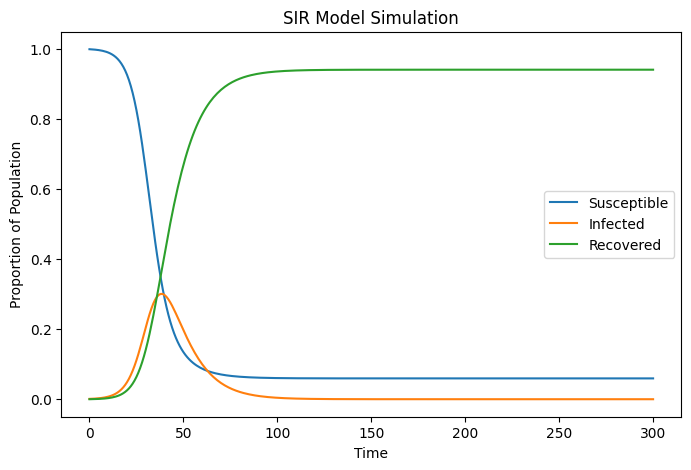

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(t, S, label="Susceptible")
plt.plot(t, I, label="Infected")
plt.plot(t, R, label="Recovered")
plt.xlabel("Time")
plt.ylabel("Proportion of Population")
plt.title("SIR Model Simulation")
plt.legend()
plt.show()


## **9. Interpretation of SIR Dynamics**

- S(t) decreases monotonically

- I(t) shows a bell-shaped curve (epidemic wave)

- R(t) increases monotonically

This reflects: rapid early transmission, peak infection, eventual exhaustion of susceptible individuals.

## **10. SIR Model with Births and Deaths**

**Motivation**

For long-term or endemic diseases (e.g., tuberculosis), the epidemic timescale is comparable to demographic timescales.
Therefore, births and deaths cannot be ignored.

Let μ denote the per-capita birth and death rate.

## **11. SIR Model with Demography**
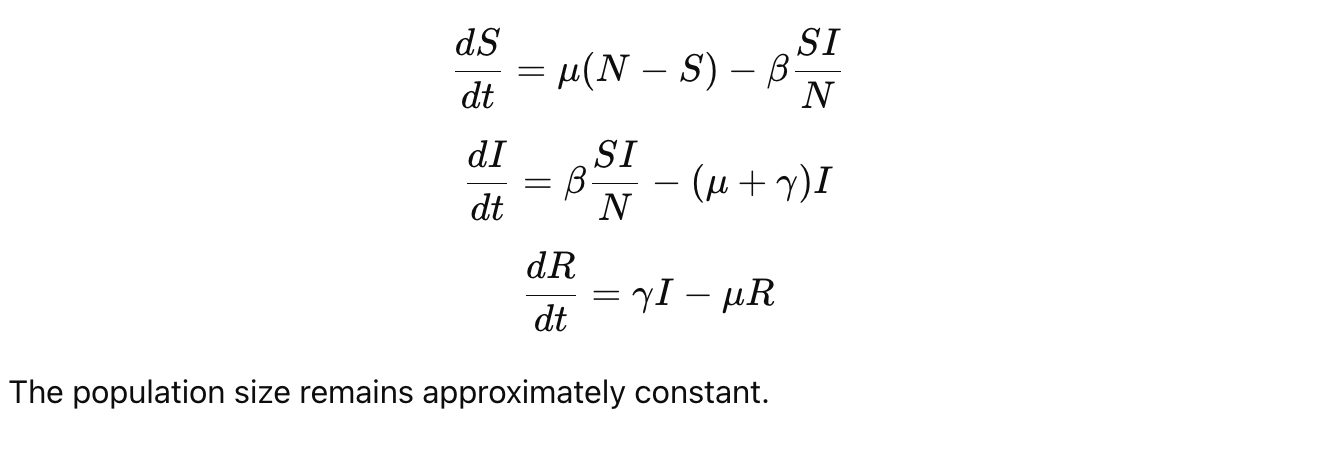

## **12. The SEIR Model (Latent Period)**

Many diseases have a latent period, during which individuals are infected but not yet infectious.

To account for this, we introduce a new compartment:

> E(t): Exposed individuals

## **13. SEIR Flow Diagram**

Susceptible (S) → Exposed (E) → Infectious (I) → Recovered (R)


## **14. SEIR Model Equations (Without Demography)**

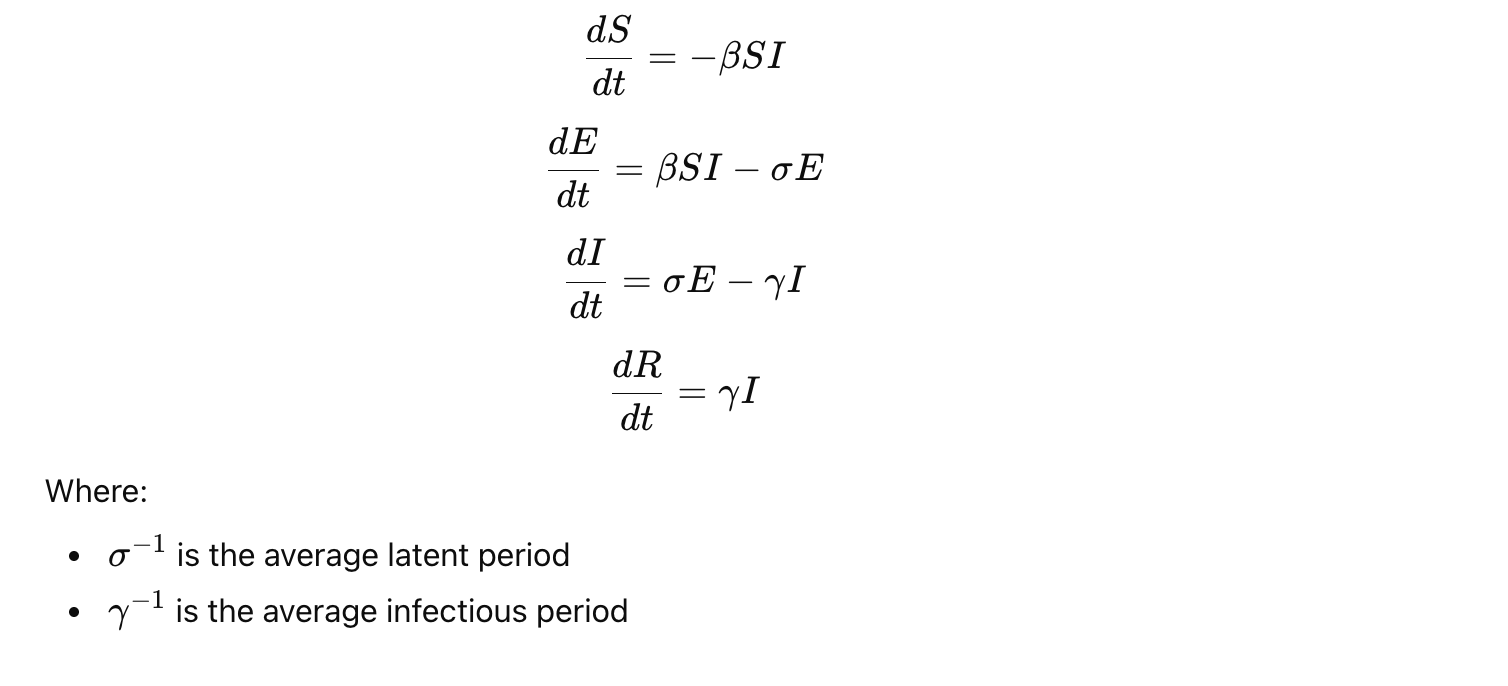

## **15. Simulating the SEIR Model in Python**
Define the SEIR Model

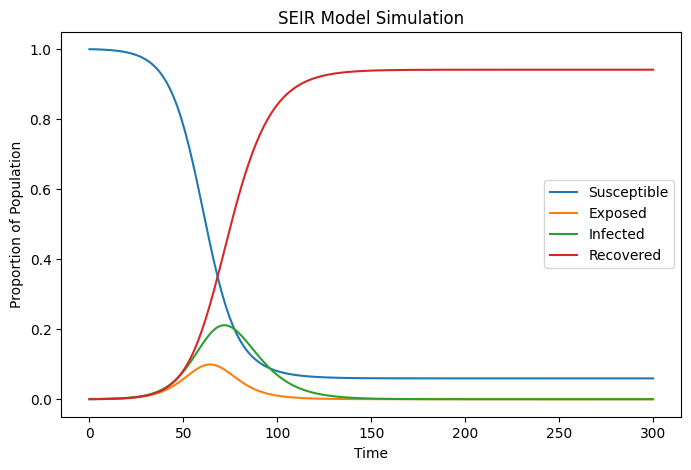

In [ ]:
def seir_model(y, t, beta, sigma, gamma):
    S, E, I, R = y
    dSdt = -beta * S * I
    dEdt = beta * S * I - sigma * E
    dIdt = sigma * E - gamma * I
    dRdt = gamma * I
    return [dSdt, dEdt, dIdt, dRdt]

#Initial Conditions and Parameters
S0 = 0.999
E0 = 0.001
I0 = 0.0
R0 = 0.0

beta = 0.3
sigma = 0.25
gamma = 0.1

t = np.linspace(0, 300, 301)

#Solve the SEIR Model

solution = odeint(seir_model, [S0, E0, I0, R0], t, args=(beta, sigma, gamma))
S, E, I, R = solution.T

#Plot the SEIR Dynamics

plt.figure(figsize=(8,5))
plt.plot(t, S, label="Susceptible")
plt.plot(t, E, label="Exposed")
plt.plot(t, I, label="Infected")
plt.plot(t, R, label="Recovered")
plt.xlabel("Time")
plt.ylabel("Proportion of Population")
plt.title("SEIR Model Simulation")
plt.legend()
plt.show()



## **16. Comparison: SIR vs SEIR**

| Feature              | SIR      | SEIR    |
| -------------------- | -------- | ------- |
| Latent period        | No       | Yes     |
| Realism              | Moderate | Higher  |
| Infection peak       | Earlier  | Delayed |
| COVID/TB suitability | Limited  | Better  |


## **17. Public Health Interpretation**

- SIR models are useful for fast-spreading outbreaks

- SEIR models are essential for diseases with incubation periods

- Bell-shaped infection curves correspond to epidemic waves

- Recovery curves represent accumulated immunity

## **18. Key Takeaway**

**SIR** and **SEIR** models are **mechanistic compartmental models** that use **systems of differential equations** to describe **disease transmission dynamics**, providing a foundation for **epidemic forecasting and public health decision-making**.